# Какие аудиохарактеристики связаны с популярностью треков Spotify?

**Дисциплина:** Анализ данных на Python  
**Команда:** Калинина Влада, Худякова Светлана

## Цель

Исследовать связи между аудиохарактеристиками треков и показателем `popularity`, проверить три статистические гипотезы и сравнить модели машинного обучения. Анализ показывает ассоциации, а не причинное влияние.

## Источники

1. [Spotify Tracks Dataset (Kaggle)](https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset) — основной набор примерно из 114 000 треков.
2. Last.fm API — слушатели, суммарные прослушивания и пользовательские теги для стратифицированной выборки популярных артистов по жанрам.

## Структура

1. Загрузка и объединение данных
2. Очистка, проверка аномалий и создание признаков
3. Разведочный анализ
4. Проверка гипотез
5. Машинное обучение и оценка пользы API-обогащения
6. Ограничения и выводы

In [1]:
from __future__ import annotations

import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GroupShuffleSplit,
    KFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
ALPHA = 0.05

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
LASTFM_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "artists_lastfm.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Корень проекта: {PROJECT_ROOT}")
print(f"Основной датасет: {RAW_DATA_PATH}")
print(f"Last.fm-обогащение: {LASTFM_DATA_PATH}")

Корень проекта: /Users/vlada/Desktop/Питон проект/spotify-popularity-analysis
Основной датасет: /Users/vlada/Desktop/Питон проект/spotify-popularity-analysis/data/raw/dataset.csv
Last.fm-обогащение: /Users/vlada/Desktop/Питон проект/spotify-popularity-analysis/data/processed/artists_lastfm.csv


---
## 1. Загрузка и объединение данных

Файл `artists_lastfm.csv` создаётся отдельным скриптом `src/enrich_lastfm.py`. Скрипт выбирает популярных артистов внутри каждого жанра, дополняет выборку глобальным рейтингом и обращается к Last.fm API. Такой подход не зависит от исходного порядка строк и обеспечивает жанровое покрытие.

In [3]:
def resolve_data_path(preferred: Path, fallback_name: str) -> Path:
    """Use the project path, with a root-level fallback for convenience."""
    fallback = PROJECT_ROOT / fallback_name
    if preferred.exists():
        return preferred
    if fallback.exists():
        return fallback
    raise FileNotFoundError(
        f"Не найден файл {preferred}. Поместите {fallback_name} в "
        f"{preferred.parent} и повторите запуск."
    )


tracks_path = resolve_data_path(RAW_DATA_PATH, "dataset.csv")
df_tracks = pd.read_csv(tracks_path, index_col=0)

required_columns = {
    "track_id",
    "track_name",
    "artists",
    "track_genre",
    "popularity",
    "explicit",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_ms",
    "mode",
}
missing_required = required_columns.difference(df_tracks.columns)
if missing_required:
    raise ValueError(
        "В основном датасете отсутствуют обязательные столбцы: "
        + ", ".join(sorted(missing_required))
    )

print(
    f"Загружено треков: {df_tracks.shape[0]:,}; "
    f"столбцов: {df_tracks.shape[1]}"
)
display(df_tracks.head())

Загружено треков: 114,000; столбцов: 20


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [4]:
def extract_primary_artist(value: object) -> str | None:
    """Возвращает первого исполнителя из списка или строки с разделителями."""
    if pd.isna(value):
        return None
    text = str(value).strip()
    if not text:
        return None
    if text.startswith(("[", "(")) and text.endswith(("]", ")")):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, (list, tuple)) and parsed:
                text = str(parsed[0])
        except (ValueError, SyntaxError):
            pass
    artist = text.split(";")[0].strip().strip("[]'\"").strip()
    return artist or None


def normalize_artist_name(value: object) -> str | None:
    artist = extract_primary_artist(value)
    if artist is None:
        return None
    return " ".join(artist.casefold().split())


df_tracks["artist_name"] = df_tracks["artists"].map(extract_primary_artist)
df_tracks["artist_key"] = df_tracks["artist_name"].map(normalize_artist_name)

lastfm_path = LASTFM_DATA_PATH
if not lastfm_path.exists() and (PROJECT_ROOT / "artists_lastfm.csv").exists():
    lastfm_path = PROJECT_ROOT / "artists_lastfm.csv"

if lastfm_path.exists():
    df_artists = pd.read_csv(lastfm_path)
    if "artist_key" not in df_artists.columns:
        df_artists["artist_key"] = df_artists["artist_name"].map(
            normalize_artist_name
        )

    df_artists = (
        df_artists.rename(
            columns={
                "listeners": "artist_listeners",
                "playcount": "artist_playcount",
                "tags": "artist_tags",
            }
        )
        .sort_values(
            "artist_listeners",
            ascending=False,
            na_position="last",
        )
        .drop_duplicates(subset="artist_key")
    )
    df = df_tracks.merge(df_artists, on="artist_key", how="left", suffixes=("", "_api"))
    if "artist_name_api" in df.columns:
        df["artist_name"] = df["artist_name"].fillna(df["artist_name_api"])

    api_matches = df["artist_listeners"].notna().sum()
    print(
        f"Last.fm: {len(df_artists):,} артистов; "
        f"реальные API-данные доступны для {api_matches:,} треков "
        f"({api_matches / len(df):.1%})."
    )
else:
    df = df_tracks.copy()
    for column in [
        "artist_listeners",
        "artist_playcount",
        "artist_tags",
        "api_status",
    ]:
        df[column] = np.nan
    print(
        "Предупреждение: artists_lastfm.csv не найден. "
        "EDA и модели на аудиопризнаках выполнятся, а API-блок будет пропущен."
    )

print(f"Размер после объединения: {df.shape}")

Last.fm: 2,998 артистов; реальные API-данные доступны для 52,071 треков (45.7%).
Размер после объединения: (114000, 34)


---
## 2. Очистка и предобработка

Принципы обработки:

- дубликаты удаляются по `track_id`;
- значения вне физически допустимых диапазонов переводятся в пропуски;
- пропуски аудиопризнаков заполняются медианой внутри жанра и затем глобальной медианой;
- корректные крайние значения не обрезаются автоматически методом IQR;
- отсутствие данных Last.fm сохраняется и не заменяется искусственным средним значением.

In [5]:
def missing_report(frame: pd.DataFrame) -> pd.DataFrame:
    report = pd.DataFrame(
        {
            "missing": frame.isna().sum(),
            "percent": frame.isna().mean().mul(100).round(2),
        }
    )
    return report.query("missing > 0").sort_values("percent", ascending=False)


print("Пропуски до очистки:")
display(missing_report(df))

rows_before = len(df)
df = df.drop_duplicates(subset="track_id").copy()
print(f"Удалено дубликатов track_id: {rows_before - len(df):,}")

Пропуски до очистки:


,missing,percent
artist_tags,63036,55.29
lastfm_name,61929,54.32
artist_playcount,61929,54.32
artist_listeners,61929,54.32
mean_spotify_popularity,61875,54.28
track_count,61875,54.28
source_genres,61875,54.28
genre_count,61875,54.28
api_status,61875,54.28
max_spotify_popularity,61875,54.28


Удалено дубликатов track_id: 24,259


In [ ]:
bounded_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
]
numeric_features = bounded_features + [
    "popularity",
    "loudness",
    "tempo",
    "duration_ms",
    "mode",
]

for column in numeric_features:
    df[column] = pd.to_numeric(df[column], errors="coerce")

invalid_popularity = ~df["popularity"].between(0, 100, inclusive="both")
print(f"Строк с недопустимой popularity: {invalid_popularity.sum():,}")
df = df.loc[~invalid_popularity].copy()

range_issues = {}
for column in bounded_features:
    invalid = ~df[column].between(0, 1, inclusive="both") & df[column].notna()
    range_issues[column] = int(invalid.sum())
    df.loc[invalid, column] = np.nan

invalid_duration = (df["duration_ms"] <= 0) & df["duration_ms"].notna()
invalid_tempo = (df["tempo"] <= 0) & df["tempo"].notna()
df.loc[invalid_duration, "duration_ms"] = np.nan
df.loc[invalid_tempo, "tempo"] = np.nan

range_report = pd.Series(range_issues, name="invalid_values").to_frame()
range_report.loc["duration_ms <= 0"] = int(invalid_duration.sum())
range_report.loc["tempo <= 0"] = int(invalid_tempo.sum())
display(range_report.query("invalid_values > 0"))

Строк с недопустимой popularity: 0


,invalid_values
duration_ms <= 0,1
tempo <= 0,157


In [7]:
def fill_with_genre_median(
    frame: pd.DataFrame,
    columns: list[str],
    group_column: str = "track_genre",
) -> pd.DataFrame:
    """Impute numeric features by genre median, then global median."""
    result = frame.copy()
    for column in columns:
        grouped_median = result.groupby(group_column)[column].transform("median")
        result[column] = result[column].fillna(grouped_median)
        result[column] = result[column].fillna(result[column].median())
    return result


audio_impute_columns = bounded_features + [
    "loudness",
    "tempo",
    "duration_ms",
]
df = fill_with_genre_median(df, audio_impute_columns)

for column in ["track_name", "artists", "track_genre"]:
    df[column] = df[column].fillna("unknown")
if "album_name" in df.columns:
    df["album_name"] = df["album_name"].fillna("unknown")

df["artist_tags"] = df["artist_tags"].fillna("not_available")

print("Пропуски после обработки основных признаков:")
display(missing_report(df))

Пропуски после обработки основных признаков:


,missing,percent
artist_listeners,51257,57.12
artist_playcount,51257,57.12
lastfm_name,51257,57.12
sample_rank,51213,57.07
artist_name_api,51213,57.07
max_spotify_popularity,51213,57.07
mean_spotify_popularity,51213,57.07
track_count,51213,57.07
genre_count,51213,57.07
source_genres,51213,57.07


In [8]:
def iqr_anomaly_summary(
    frame: pd.DataFrame,
    columns: list[str],
) -> pd.DataFrame:
    rows = []
    for column in columns:
        q1 = frame[column].quantile(0.25)
        q3 = frame[column].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        count = ((frame[column] < lower) | (frame[column] > upper)).sum()
        rows.append(
            {
                "feature": column,
                "lower_iqr_bound": lower,
                "upper_iqr_bound": upper,
                "iqr_anomalies": int(count),
                "share": count / len(frame),
            }
        )
    return pd.DataFrame(rows)


anomaly_summary = iqr_anomaly_summary(
    df,
    ["popularity", "duration_ms", "loudness", "tempo"],
)
display(anomaly_summary.style.format({"share": "{:.2%}"}))

print(
    "IQR здесь используется для диагностики. Значения popularity 0–100 "
    "и реальные длинные/быстрые треки не обрезаются автоматически."
)

,feature,lower_iqr_bound,upper_iqr_bound,iqr_anomalies,share
0,popularity,-26.000000,94.000000,11,0.01%
1,duration_ms,36160.500000,401172.500000,4225,4.71%
2,loudness,-18.143000,2.713000,5026,5.60%
3,tempo,38.094500,201.266500,357,0.40%


IQR здесь используется для диагностики. Значения popularity 0–100 и реальные длинные/быстрые треки не обрезаются автоматически.


In [9]:
def to_binary_flag(value: object) -> int:
    if pd.isna(value):
        return 0
    if isinstance(value, (bool, np.bool_)):
        return int(value)
    return int(str(value).strip().casefold() in {"true", "1", "yes"})


df["explicit_flag"] = df["explicit"].map(to_binary_flag)
df["explicit_label"] = df["explicit_flag"].map(
    {0: "Без пометки", 1: "С пометкой"}
)

df["mode_binary"] = pd.to_numeric(df["mode"], errors="coerce")
df["mode_label"] = df["mode_binary"].map({0: "minor", 1: "major"})

df["duration_min"] = df["duration_ms"] / 60_000
df["positive_energy_index"] = (df["energy"] + df["valence"]) / 2

df["popularity_category"] = pd.cut(
    df["popularity"],
    bins=[0, 25, 50, 75, 100],
    labels=["Низкая", "Средняя", "Высокая", "Топ"],
    include_lowest=True,
)

df["has_lastfm_data"] = (
    df["artist_listeners"].notna() & df["artist_playcount"].notna()
)
df["log_artist_listeners"] = np.where(
    df["has_lastfm_data"],
    np.log1p(df["artist_listeners"]),
    np.nan,
)
df["log_artist_playcount"] = np.where(
    df["has_lastfm_data"],
    np.log1p(df["artist_playcount"]),
    np.nan,
)

print(f"Финальный размер аналитической таблицы: {df.shape}")
print(
    "Доля строк с реальными Last.fm-признаками: "
    f"{df['has_lastfm_data'].mean():.1%}"
)
display(
    df[
        [
            "track_name",
            "artist_name",
            "duration_min",
            "popularity_category",
            "has_lastfm_data",
            "log_artist_listeners",
        ]
    ].head()
)

Финальный размер аналитической таблицы: (89741, 44)
Доля строк с реальными Last.fm-признаками: 42.9%


,track_name,artist_name,duration_min,popularity_category,has_lastfm_data,log_artist_listeners
0,Comedy,Gen Hoshino,3.844433,Высокая,True,12.425670
1,Ghost - Acoustic,Ben Woodward,2.493500,Высокая,False,NaN
2,To Begin Again,Ingrid Michaelson,3.513767,Высокая,False,NaN
3,Can't Help Falling In Love,Kina Grannis,3.365550,Высокая,True,13.256674
4,Hold On,Chord Overstreet,3.314217,Топ,True,12.962413


### Промежуточный вывод по очистке

Основные аудиопризнаки приведены к корректным диапазонам, дубликаты удалены, а числовые пропуски обработаны статистически с учётом жанра. IQR-аномалии проанализированы, но допустимые крайние значения не искажались обрезанием. Признаки Last.fm остаются пропущенными там, где реального ответа API нет.

---
## 3. Разведочный анализ данных

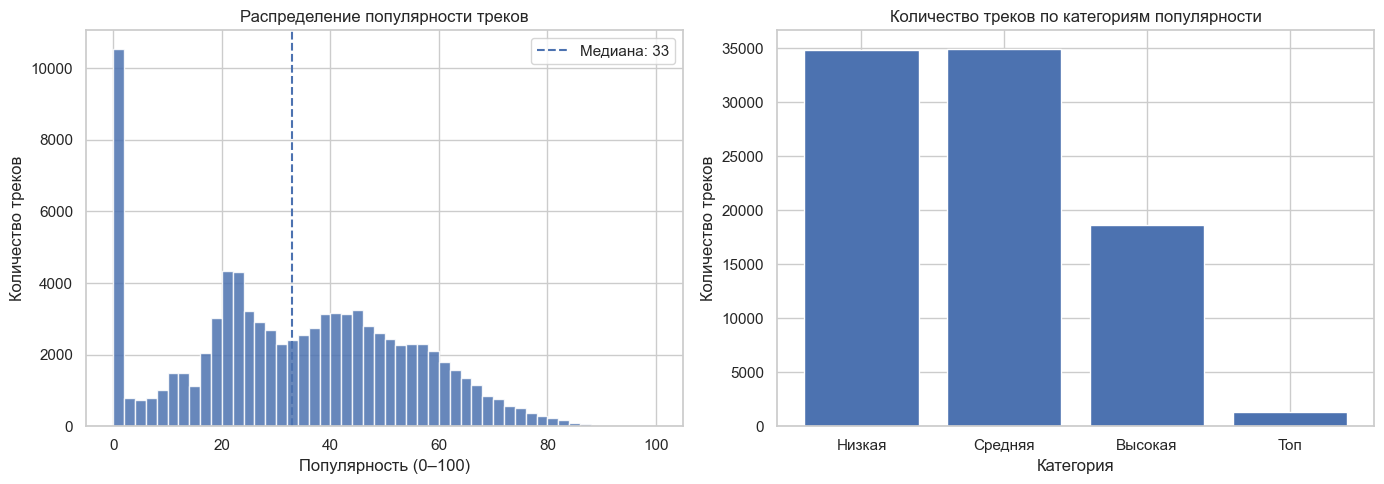

Средняя популярность: 33.20
Медианная популярность: 33.00


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df["popularity"],
    bins=50,
    edgecolor="white",
    alpha=0.85,
)
axes[0].axvline(
    df["popularity"].median(),
    linestyle="--",
    label=f"Медиана: {df['popularity'].median():.0f}",
)
axes[0].set(
    title="Распределение популярности треков",
    xlabel="Популярность (0–100)",
    ylabel="Количество треков",
)
axes[0].legend()

category_order = ["Низкая", "Средняя", "Высокая", "Топ"]
category_counts = (
    df["popularity_category"]
    .value_counts(sort=False)
    .reindex(category_order)
    .fillna(0)
)
axes[1].bar(category_counts.index, category_counts.values)
axes[1].set(
    title="Количество треков по категориям популярности",
    xlabel="Категория",
    ylabel="Количество треков",
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "01_popularity_distribution.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print(f"Средняя популярность: {df['popularity'].mean():.2f}")
print(f"Медианная популярность: {df['popularity'].median():.2f}")

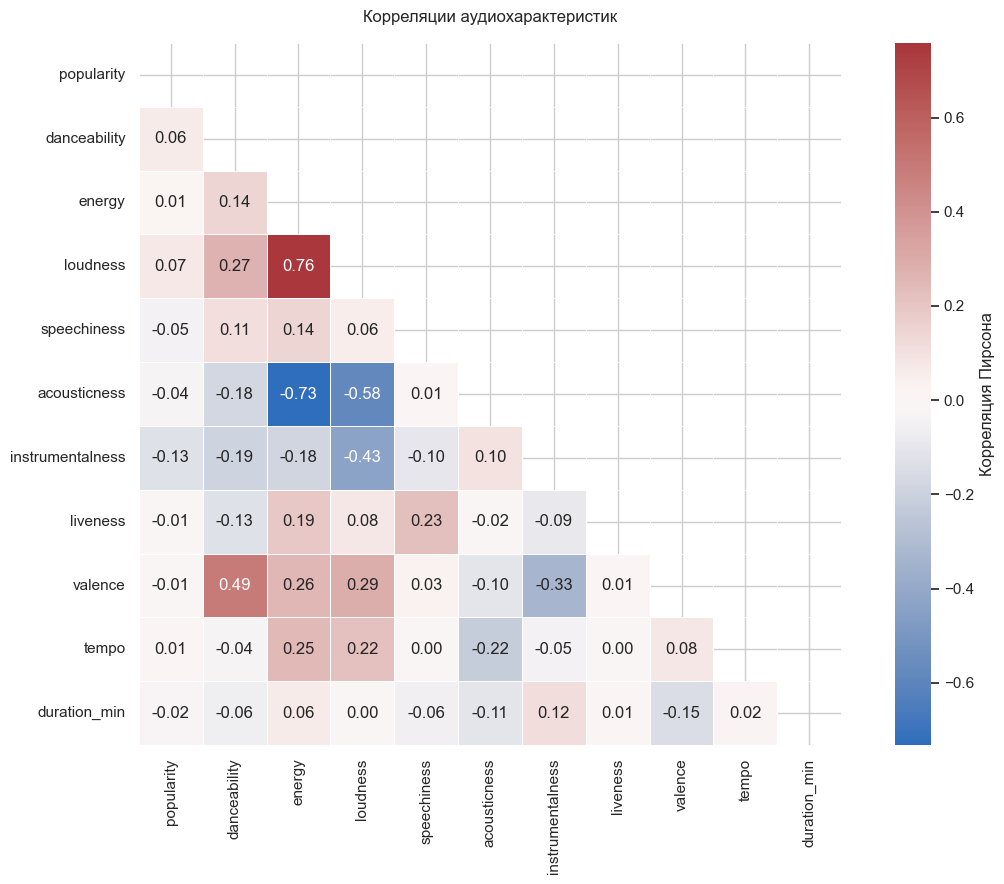

In [11]:
correlation_features = [
    "popularity",
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min",
]
correlation_matrix = df[correlation_features].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(12, 9))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="vlag",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Корреляция Пирсона"},
)
plt.title("Корреляции аудиохарактеристик", pad=15)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "02_correlation_heatmap.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

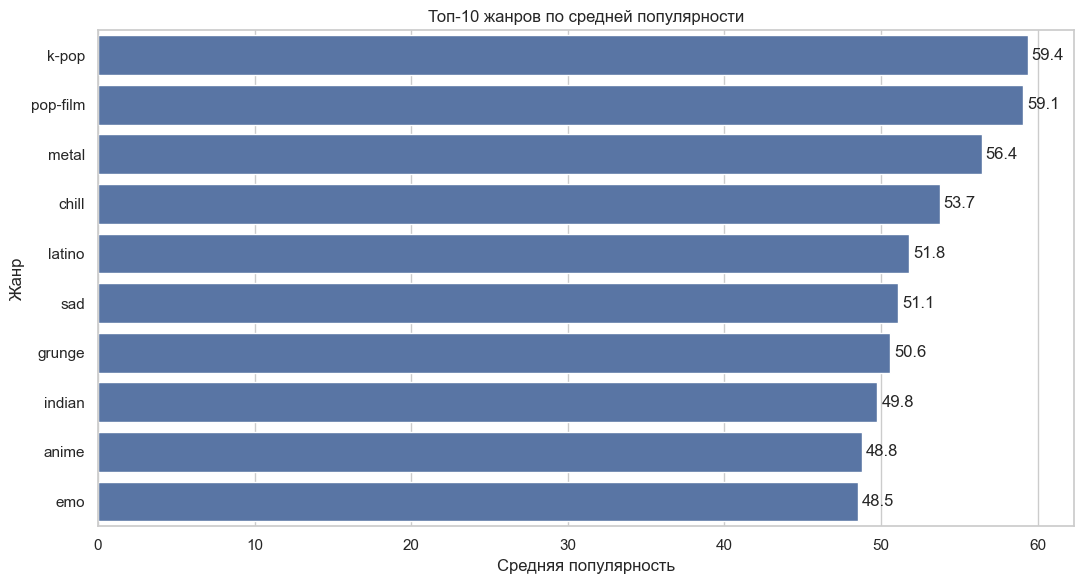

,track_genre,mean,median,count
0,k-pop,59.358779,61.0,917
1,pop-film,59.096933,60.0,815
2,metal,56.422414,63.0,232
3,chill,53.738683,57.0,972
4,latino,51.788945,46.0,398
5,sad,51.109929,52.0,564
6,grunge,50.587007,54.0,862
7,indian,49.765348,49.0,733
8,anime,48.776884,50.0,995
9,emo,48.500000,50.0,932


In [12]:
top_genres = (
    df.groupby("track_genre")["popularity"]
    .agg(mean="mean", median="median", count="size")
    .query("count >= 100")
    .sort_values("mean", ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=top_genres,
    y="track_genre",
    x="mean",
    order=top_genres["track_genre"],
    color="C0",
)
ax.set(
    title="Топ-10 жанров по средней популярности",
    xlabel="Средняя популярность",
    ylabel="Жанр",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "03_top_genres.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
display(top_genres)

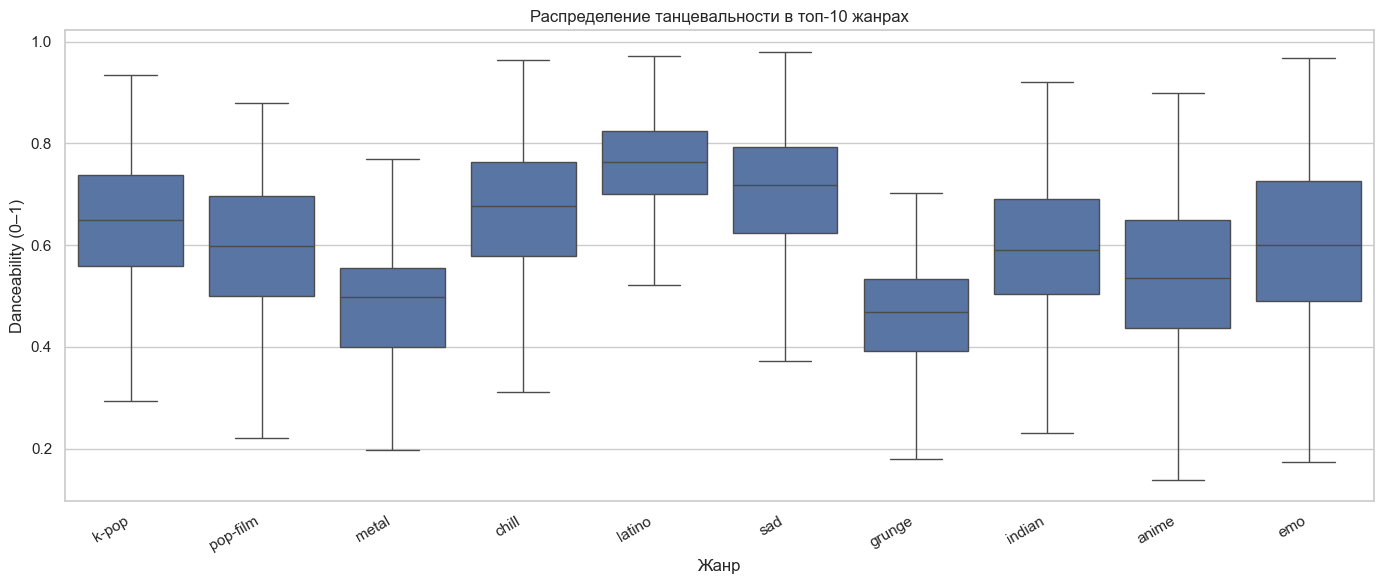

In [13]:
top_genre_names = top_genres["track_genre"].tolist()
df_top_genres = df[df["track_genre"].isin(top_genre_names)]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top_genres,
    x="track_genre",
    y="danceability",
    order=top_genre_names,
    showfliers=False,
    color="C0",
)
plt.title("Распределение танцевальности в топ-10 жанрах")
plt.xlabel("Жанр")
plt.ylabel("Danceability (0–1)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "04_danceability_by_genre.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

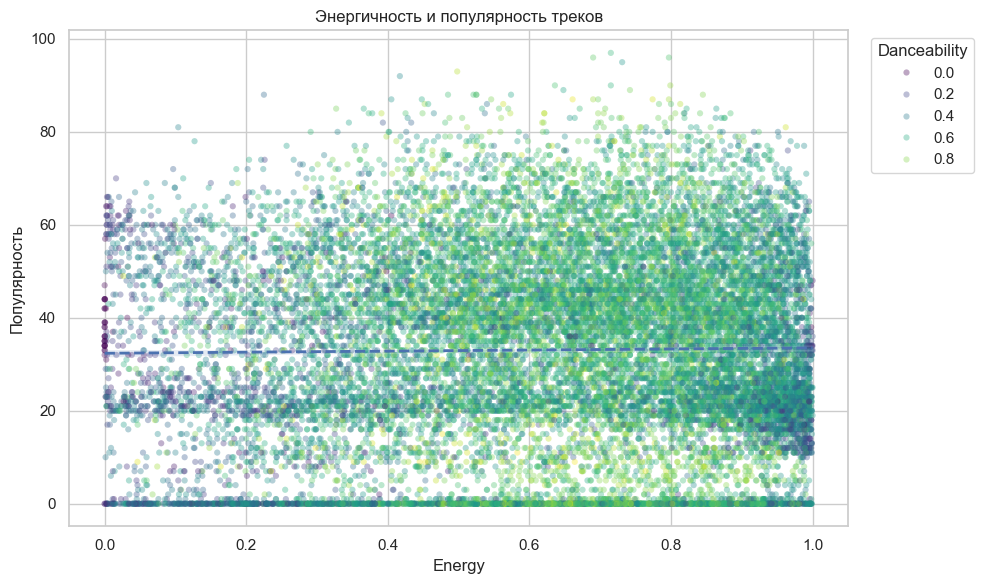

In [14]:
plot_sample = df.sample(
    n=min(20_000, len(df)),
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample,
    x="energy",
    y="popularity",
    hue="danceability",
    palette="viridis",
    alpha=0.35,
    s=20,
    linewidth=0,
)
sns.regplot(
    data=plot_sample,
    x="energy",
    y="popularity",
    scatter=False,
    line_kws={"linestyle": "--", "linewidth": 2},
)
plt.title("Энергичность и популярность треков")
plt.xlabel("Energy")
plt.ylabel("Популярность")
plt.legend(title="Danceability", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "05_energy_vs_popularity.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

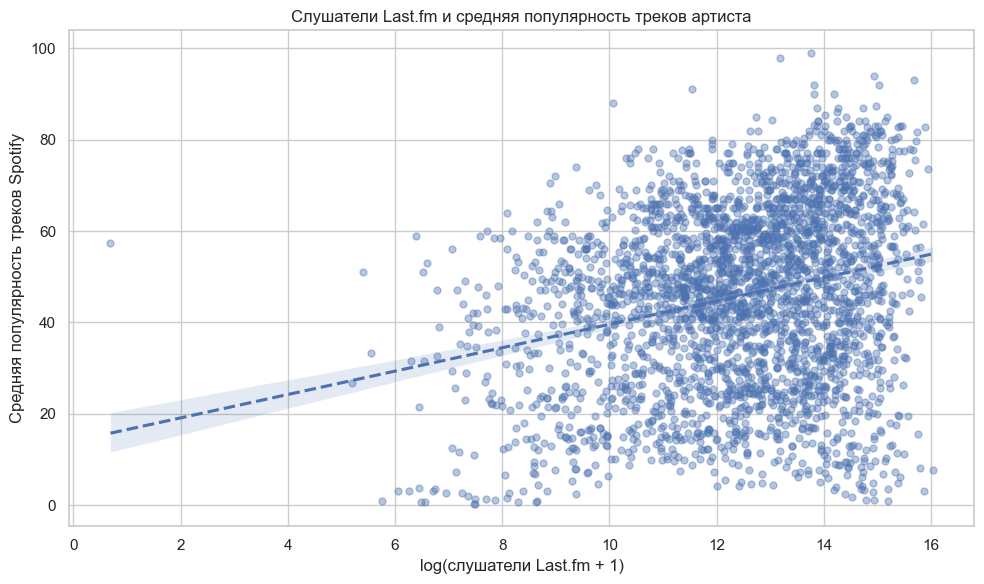

In [15]:
artist_level = (
    df.loc[df["has_lastfm_data"]]
    .groupby("artist_key", as_index=False)
    .agg(
        artist_name=("artist_name", "first"),
        mean_track_popularity=("popularity", "mean"),
        artist_listeners=("artist_listeners", "first"),
        track_count=("track_id", "nunique"),
    )
)

if len(artist_level) >= 2:
    artist_level["log_artist_listeners"] = np.log1p(
        artist_level["artist_listeners"]
    )
    plt.figure(figsize=(10, 6))
    sns.regplot(
        data=artist_level,
        x="log_artist_listeners",
        y="mean_track_popularity",
        scatter_kws={"alpha": 0.4, "s": 25},
        line_kws={"linestyle": "--"},
        color="C0",
    )
    plt.title("Слушатели Last.fm и средняя популярность треков артиста")
    plt.xlabel("log(слушатели Last.fm + 1)")
    plt.ylabel("Средняя популярность треков Spotify")
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "06_lastfm_listeners_vs_popularity.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("График Last.fm пропущен: недостаточно реальных API-наблюдений.")

### Промежуточный вывод по EDA

Графики позволяют увидеть форму распределений, различия между жанрами и направление парных связей. Однако визуальная линия тренда не доказывает сильную или причинную зависимость. Ниже связи проверяются статистически, а их практическая величина оценивается с помощью коэффициентов корреляции и размеров эффектов.

---
## 4. Проверка гипотез

Уровень значимости: **α = 0,05**. При больших выборках p-value обязательно рассматривается вместе с величиной эффекта.

In [16]:
def cohens_d(first: pd.Series, second: pd.Series) -> float:
    """Calculate Cohen's d using the pooled sample standard deviation."""
    first = first.dropna().astype(float)
    second = second.dropna().astype(float)
    pooled_variance = (
        (len(first) - 1) * first.var(ddof=1)
        + (len(second) - 1) * second.var(ddof=1)
    ) / (len(first) + len(second) - 2)
    return (first.mean() - second.mean()) / np.sqrt(pooled_variance)


def effect_label(value: float) -> str:
    magnitude = abs(value)
    if magnitude < 0.2:
        return "очень малый"
    if magnitude < 0.5:
        return "малый"
    if magnitude < 0.8:
        return "средний"
    return "большой"

### Гипотеза 1: explicit-треки в среднем популярнее

- **H₀:** средняя популярность explicit-треков не выше.
- **H₁:** средняя популярность explicit-треков выше.

Используется односторонний Welch t-test, который не предполагает равенство дисперсий групп.

In [17]:
explicit_tracks = df.loc[df["explicit_flag"] == 1, "popularity"]
non_explicit_tracks = df.loc[df["explicit_flag"] == 0, "popularity"]

explicit_test = stats.ttest_ind(
    explicit_tracks,
    non_explicit_tracks,
    equal_var=False,
    alternative="greater",
)
explicit_d = cohens_d(explicit_tracks, non_explicit_tracks)
explicit_difference = explicit_tracks.mean() - non_explicit_tracks.mean()

print(
    f"Explicit: n={len(explicit_tracks):,}, "
    f"mean={explicit_tracks.mean():.2f}"
)
print(
    f"Non-explicit: n={len(non_explicit_tracks):,}, "
    f"mean={non_explicit_tracks.mean():.2f}"
)
print(f"Разница средних: {explicit_difference:.2f}")
print(f"Welch t = {explicit_test.statistic:.3f}")
print(f"Односторонний p-value = {explicit_test.pvalue:.3e}")
print(
    f"Cohen's d = {explicit_d:.3f} "
    f"({effect_label(explicit_d)} эффект)"
)

if explicit_test.pvalue < ALPHA and explicit_difference > 0:
    print(
        "Вывод: H₀ отвергается, но практическая значимость "
        "определяется величиной Cohen's d, а не только p-value."
    )
else:
    print("Вывод: данных недостаточно для поддержки направленной H₁.")

Explicit: n=7,704, mean=36.89
Non-explicit: n=82,037, mean=32.85
Разница средних: 4.03
Welch t = 15.254
Односторонний p-value = 3.475e-52
Cohen's d = 0.196 (очень малый эффект)
Вывод: H₀ отвергается, но практическая значимость определяется величиной Cohen's d, а не только p-value.


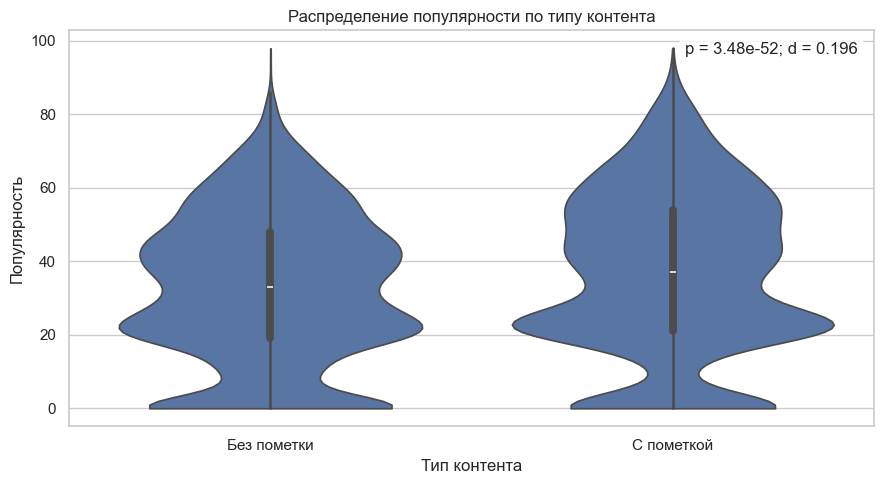

In [18]:
violin_parts = []
for label, group in df.groupby("explicit_label"):
    violin_parts.append(
        group.sample(
            n=min(10_000, len(group)),
            random_state=RANDOM_STATE,
        )
    )
violin_data = pd.concat(violin_parts, ignore_index=True)

plt.figure(figsize=(9, 5))
sns.violinplot(
    data=violin_data,
    x="explicit_label",
    y="popularity",
    order=["Без пометки", "С пометкой"],
    inner="box",
    cut=0,
    color="C0",
)
plt.title("Распределение популярности по типу контента")
plt.xlabel("Тип контента")
plt.ylabel("Популярность")
plt.text(
    0.98,
    0.97,
    f"p = {explicit_test.pvalue:.2e}; d = {explicit_d:.3f}",
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.8},
)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "07_explicit_violin.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

### Гипотеза 2: танцевальность положительно связана с популярностью

Проверяются линейная корреляция Пирсона и ранговая корреляция Спирмена. Даже статистически значимый коэффициент около нуля означает практически слабую связь.

In [19]:
pearson_result = stats.pearsonr(df["danceability"], df["popularity"])
spearman_result = stats.spearmanr(df["danceability"], df["popularity"])

print(
    f"Пирсон: r = {pearson_result.statistic:.4f}, "
    f"p = {pearson_result.pvalue:.3e}"
)
print(
    f"Спирмен: ρ = {spearman_result.statistic:.4f}, "
    f"p = {spearman_result.pvalue:.3e}"
)

if pearson_result.pvalue < ALPHA and pearson_result.statistic > 0:
    print(
        "Вывод: положительная связь статистически обнаруживается, "
        "но её практическая сила оценивается по абсолютному значению r."
    )
else:
    print("Вывод: положительная линейная связь не подтверждена.")

Пирсон: r = 0.0643, p = 8.533e-83
Спирмен: ρ = 0.0553, p = 9.823e-62
Вывод: положительная связь статистически обнаруживается, но её практическая сила оценивается по абсолютному значению r.


### Гипотеза 3: мажорные треки в среднем популярнее минорных

- **H₀:** средняя популярность мажорных треков не выше.
- **H₁:** средняя популярность мажорных треков выше.

Дополнительно выводится двусторонний тест, чтобы увидеть возможное различие в противоположном направлении.

In [20]:
major_popularity = df.loc[df["mode_label"] == "major", "popularity"]
minor_popularity = df.loc[df["mode_label"] == "minor", "popularity"]

major_one_sided = stats.ttest_ind(
    major_popularity,
    minor_popularity,
    equal_var=False,
    alternative="greater",
)
major_two_sided = stats.ttest_ind(
    major_popularity,
    minor_popularity,
    equal_var=False,
    alternative="two-sided",
)
mode_d = cohens_d(major_popularity, minor_popularity)
mode_difference = major_popularity.mean() - minor_popularity.mean()

print(
    f"Major: n={len(major_popularity):,}, "
    f"mean={major_popularity.mean():.2f}"
)
print(
    f"Minor: n={len(minor_popularity):,}, "
    f"mean={minor_popularity.mean():.2f}"
)
print(f"Major − minor: {mode_difference:.2f}")
print(f"Односторонний p-value для H₁: {major_one_sided.pvalue:.3e}")
print(f"Двусторонний p-value: {major_two_sided.pvalue:.3e}")
print(f"Cohen's d = {mode_d:.3f} ({effect_label(mode_d)} эффект)")

if major_one_sided.pvalue < ALPHA and mode_difference > 0:
    print("Вывод: направленная H₁ поддерживается.")
else:
    print("Вывод: направленная гипотеза «major > minor» не поддерживается.")
    if major_two_sided.pvalue < ALPHA:
        direction = "major" if mode_difference > 0 else "minor"
        print(
            f"При этом двусторонний тест обнаруживает различие в пользу "
            f"{direction}; оцените его практическую величину по Cohen's d."
        )

Major: n=57,162, mean=32.95
Minor: n=32,579, mean=33.64
Major − minor: -0.69
Односторонний p-value для H₁: 1.000e+00
Двусторонний p-value: 1.379e-06
Cohen's d = -0.034 (очень малый эффект)
Вывод: направленная гипотеза «major > minor» не поддерживается.
При этом двусторонний тест обнаруживает различие в пользу minor; оцените его практическую величину по Cohen's d.


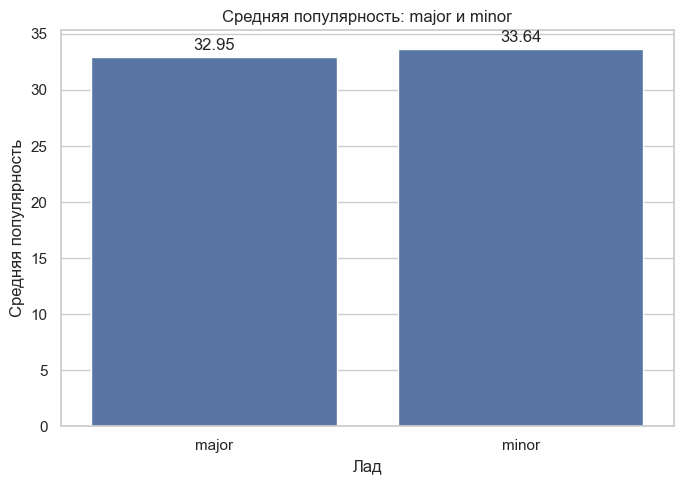

,mode_label,mean,median,count
0,major,32.946520,33.0,57162
1,minor,33.640443,34.0,32579


In [21]:
mode_summary = (
    df.groupby("mode_label", observed=True)["popularity"]
    .agg(mean="mean", median="median", count="size")
    .reset_index()
)

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=mode_summary, x="mode_label", y="mean", color="C0"
)
ax.set(
    title="Средняя популярность: major и minor",
    xlabel="Лад",
    ylabel="Средняя популярность",
)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "08_mode_popularity.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
display(mode_summary)

---
## 5. Машинное обучение

Сначала сравниваются четыре модели на аудиопризнаках, включая простую baseline-модель. Масштабирование линейной регрессии выполняется внутри `Pipeline`, поэтому параметры стандартизации оцениваются только по обучающим данным. Для оценки используются MAE, RMSE, R² и трёхкратная кросс-валидация.

`positive_energy_index` не включён вместе с `energy` и `valence`, поскольку является их линейной комбинацией и создавал бы точную мультиколлинеарность.

In [22]:
base_feature_columns = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "duration_min",
    "explicit_flag",
    "mode_binary",
]

df_model = df[base_feature_columns + ["popularity"]].dropna().copy()
X = df_model[base_feature_columns]
y = df_model["popularity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

print(f"Обучающая выборка: {len(X_train):,}")
print(f"Тестовая выборка: {len(X_test):,}")

Обучающая выборка: 71,792
Тестовая выборка: 17,949


In [23]:
models = {
    "Dummy mean": DummyRegressor(strategy="mean"),
    "Linear regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("regressor", LinearRegression()),
        ]
    ),
    "Decision tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=20,
        random_state=RANDOM_STATE,
    ),
    "Random forest": RandomForestRegressor(
        n_estimators=120,
        min_samples_leaf=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2",
}

model_rows = []
fitted_models = {}
test_predictions = {}

for model_name, estimator in models.items():
    cv_result = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
    )

    fitted = clone(estimator).fit(X_train, y_train)
    prediction = fitted.predict(X_test)

    fitted_models[model_name] = fitted
    test_predictions[model_name] = prediction
    model_rows.append(
        {
            "model": model_name,
            "cv_mae": -cv_result["test_mae"].mean(),
            "cv_rmse": -cv_result["test_rmse"].mean(),
            "cv_r2": cv_result["test_r2"].mean(),
            "cv_r2_std": cv_result["test_r2"].std(),
            "test_mae": mean_absolute_error(y_test, prediction),
            "test_rmse": np.sqrt(mean_squared_error(y_test, prediction)),
            "test_r2": r2_score(y_test, prediction),
        }
    )

model_results = (
    pd.DataFrame(model_rows)
    .sort_values("test_r2", ascending=False)
    .reset_index(drop=True)
)
display(model_results.style.format(precision=3))

,model,cv_mae,cv_rmse,cv_r2,cv_r2_std,test_mae,test_rmse,test_r2
0,Random forest,14.327,18.233,0.218,0.001,13.900,17.811,0.241
1,Decision tree,15.891,19.794,0.078,0.003,15.668,19.589,0.081
2,Linear regression,16.689,20.261,0.034,0.000,16.582,20.127,0.030
3,Dummy mean,17.262,20.616,-0.000,0.000,17.121,20.438,-0.000


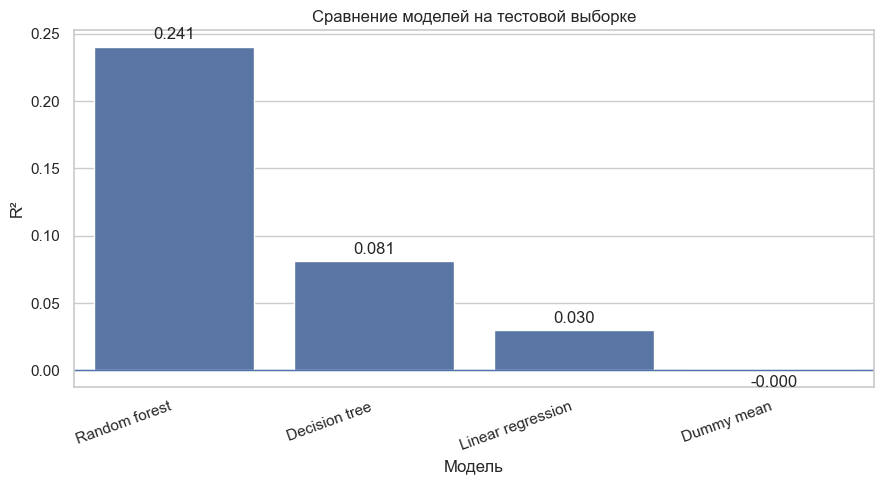

In [24]:
plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=model_results, x="model", y="test_r2", color="C0"
)
ax.axhline(0, linewidth=1)
ax.set(
    title="Сравнение моделей на тестовой выборке",
    xlabel="Модель",
    ylabel="R²",
)
plt.xticks(rotation=20, ha="right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "09_model_comparison.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

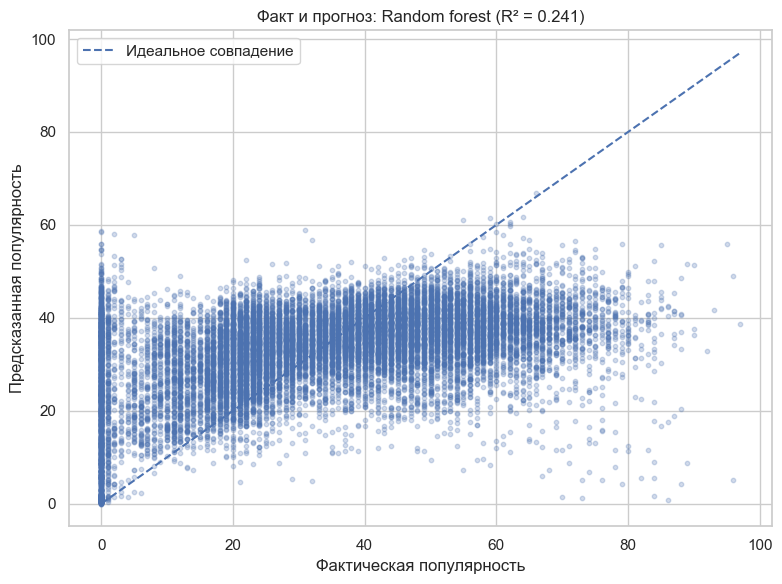

In [25]:
best_model_name = model_results.loc[0, "model"]
best_prediction = test_predictions[best_model_name]
best_r2 = model_results.loc[0, "test_r2"]

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_prediction, alpha=0.25, s=10)
limits = [min(y_test.min(), best_prediction.min()), max(y_test.max(), best_prediction.max())]
plt.plot(limits, limits, linestyle="--", label="Идеальное совпадение")
plt.title(f"Факт и прогноз: {best_model_name} (R² = {best_r2:.3f})")
plt.xlabel("Фактическая популярность")
plt.ylabel("Предсказанная популярность")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "10_actual_vs_predicted.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

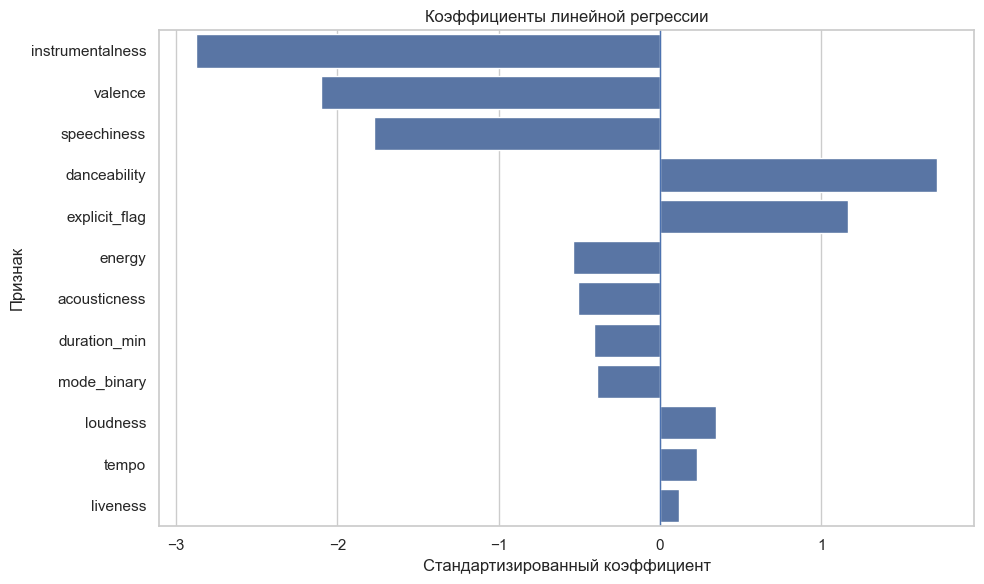

,feature,standardized_coefficient
5,instrumentalness,-2.874247
7,valence,-2.104876
3,speechiness,-1.773240
0,danceability,1.715968
10,explicit_flag,1.164459
1,energy,-0.542066
4,acousticness,-0.506049
9,duration_min,-0.407337
11,mode_binary,-0.388517
2,loudness,0.347532


In [26]:
linear_pipeline = fitted_models["Linear regression"]
linear_coefficients = pd.DataFrame(
    {
        "feature": base_feature_columns,
        "standardized_coefficient": linear_pipeline.named_steps[
            "regressor"
        ].coef_,
    }
).sort_values("standardized_coefficient", key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=linear_coefficients,
    y="feature",
    x="standardized_coefficient",
    color="C0",
)
plt.axvline(0, linewidth=1)
plt.title("Коэффициенты линейной регрессии")
plt.xlabel("Стандартизированный коэффициент")
plt.ylabel("Признак")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "11_linear_coefficients.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
display(linear_coefficients)

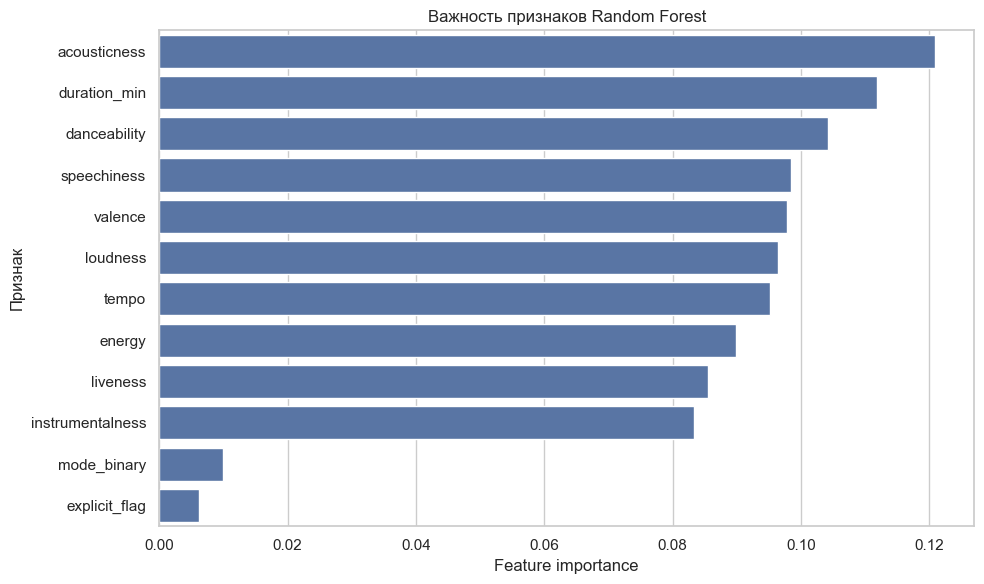

,feature,importance
0,acousticness,0.120940
1,duration_min,0.111867
2,danceability,0.104283
3,speechiness,0.098420
4,valence,0.097890
5,loudness,0.096443
6,tempo,0.095230
7,energy,0.089892
8,liveness,0.085516
9,instrumentalness,0.083363


In [27]:
forest_model = fitted_models["Random forest"]
forest_importance = (
    pd.DataFrame(
        {
            "feature": base_feature_columns,
            "importance": forest_model.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=forest_importance, y="feature", x="importance", color="C0"
)
plt.title("Важность признаков Random Forest")
plt.xlabel("Feature importance")
plt.ylabel("Признак")
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "12_random_forest_importance.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()
display(forest_importance)

### 5.2 Даёт ли API-обогащение дополнительный сигнал?

Сравнение проводится только на строках с реальными Last.fm-данными. Обе модели получают одинаковые объекты, а разделение выполняется по артистам: треки одного исполнителя не попадают одновременно в обучение и тест. Это уменьшает утечку информации через повторяющиеся артистические показатели.

,model,mae,rmse,r2
0,Только аудиопризнаки,20.020,24.427,0.039
1,Аудио + Last.fm,19.106,24.348,0.045


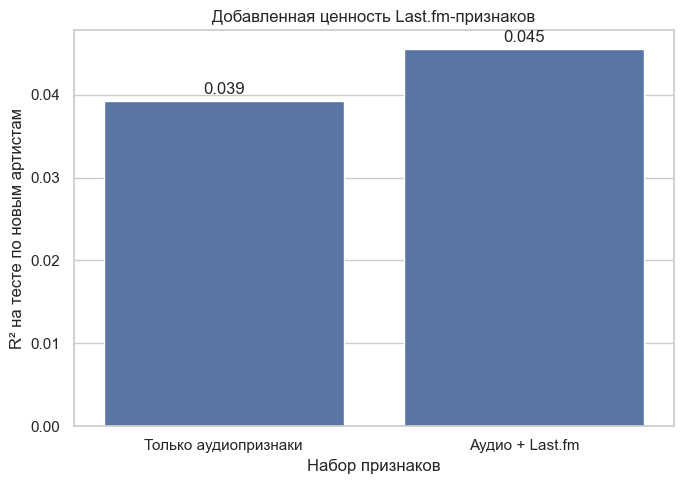

In [28]:
api_feature_columns = base_feature_columns + [
    "log_artist_listeners",
    "log_artist_playcount",
]
api_model_frame = df[
    api_feature_columns + ["popularity", "artist_key"]
].dropna()

api_comparison = None
minimum_artists = 50
unique_api_artists = api_model_frame["artist_key"].nunique()

if len(api_model_frame) >= 500 and unique_api_artists >= minimum_artists:
    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=RANDOM_STATE,
    )
    train_positions, test_positions = next(
        splitter.split(
            api_model_frame,
            groups=api_model_frame["artist_key"],
        )
    )
    train_api = api_model_frame.iloc[train_positions]
    test_api = api_model_frame.iloc[test_positions]

    comparison_models = {
        "Только аудиопризнаки": RandomForestRegressor(
            n_estimators=120,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "Аудио + Last.fm": RandomForestRegressor(
            n_estimators=120,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }

    api_rows = []
    for model_name, estimator in comparison_models.items():
        columns = (
            base_feature_columns
            if model_name == "Только аудиопризнаки"
            else api_feature_columns
        )
        estimator.fit(train_api[columns], train_api["popularity"])
        prediction = estimator.predict(test_api[columns])
        api_rows.append(
            {
                "model": model_name,
                "mae": mean_absolute_error(test_api["popularity"], prediction),
                "rmse": np.sqrt(
                    mean_squared_error(test_api["popularity"], prediction)
                ),
                "r2": r2_score(test_api["popularity"], prediction),
            }
        )

    api_comparison = pd.DataFrame(api_rows)
    display(api_comparison.style.format(precision=3))

    plt.figure(figsize=(7, 5))
    ax = sns.barplot(
        data=api_comparison, x="model", y="r2", color="C0"
    )
    ax.set(
        title="Добавленная ценность Last.fm-признаков",
        xlabel="Набор признаков",
        ylabel="R² на тесте по новым артистам",
    )
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=3)
    plt.tight_layout()
    plt.savefig(
        FIGURES_DIR / "13_lastfm_added_value.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
else:
    print(
        "API-сравнение пропущено: требуется не менее 500 строк и "
        f"{minimum_artists} уникальных артистов с реальными Last.fm-данными."
    )

---
## 6. Итоговые выводы

In [ ]:
print("КЛЮЧЕВЫЕ ЧИСЛЕННЫЕ РЕЗУЛЬТАТЫ")
print(
    f"Explicit − non-explicit: {explicit_difference:.2f} пункта; "
    f"Cohen's d = {explicit_d:.3f}; p = {explicit_test.pvalue:.2e}."
)
print(
    f"Danceability: Pearson r = {pearson_result.statistic:.4f}; "
    f"Spearman ρ = {spearman_result.statistic:.4f}."
)
print(
    f"Major − minor: {mode_difference:.2f} пункта; "
    f"Cohen's d = {mode_d:.3f}; "
    f"p(H1 major > minor) = {major_one_sided.pvalue:.2e}."
)
print(
    f"Лучшая базовая модель: {best_model_name}; "
    f"test R² = {best_r2:.3f}; "
    f"test RMSE = {model_results.loc[0, 'test_rmse']:.2f}."
)

if api_comparison is not None:
    audio_r2 = api_comparison.loc[
        api_comparison["model"] == "Только аудиопризнаки", "r2"
    ].iloc[0]
    enriched_r2 = api_comparison.loc[
        api_comparison["model"] == "Аудио + Last.fm", "r2"
    ].iloc[0]
    print(
        f"Изменение R² после добавления Last.fm: "
        f"{enriched_r2 - audio_r2:+.3f}."
    )

КЛЮЧЕВЫЕ ЧИСЛЕННЫЕ РЕЗУЛЬТАТЫ
---------------------------------------------
Explicit − non-explicit: 4.03 пункта; Cohen's d = 0.196; p = 3.48e-52.
Danceability: Pearson r = 0.0643; Spearman ρ = 0.0553.
Major − minor: -0.69 пункта; Cohen's d = -0.034; p(H1 major > minor) = 1.00e+00.
Лучшая базовая модель: Random forest; test R² = 0.241; test RMSE = 17.81.
Изменение R² после добавления Last.fm: +0.006.


### Содержательная интерпретация
1. **Статистическая значимость не равна практической.** На десятках тысяч треков даже очень слабые связи могут иметь малый p-value, поэтому основное внимание уделяется размерам эффектов и качеству прогноза.
2. **Танцевальность не является самостоятельным сильным объяснением популярности.** Связь по Пирсону и Спирману можно охарактеризовать как очень слабую, p-value так же очень мало, что показывает лишь статистическую значимость связи (на практике она не имеет никакой значимости).
3. **Направленная гипотеза о преимуществе мажора не принимается.** На основании того, что разница отрицательна и p-value = 1 H₁ отклоняется. Наблюдаемое преимущество минора статистически достоверно, но содержательно незначимо.
4. **Модели на аудиопризнаках имеют ограниченную объясняющую способность.** R² остаётся умеренным или низким и нельзя заявлять о точном прогнозировании успеха новых релизов.
5. **Польза Last.fm проверяется отдельным экспериментом.** Рост R² на тех же объектах и при разделении по артистам свидетельствует о дополнительном сигнале. Отсутствие роста также является содержательным результатом.

### Ограничения

- показатель Spotify `popularity` является платформенной метрикой и может зависеть от момента выгрузки;
- Last.fm и Spotify имеют разные аудитории;
- несколько треков одного артиста не являются полностью независимыми наблюдениями;
- данные не содержат всех факторов продвижения, плейлистов, даты релиза и маркетинга;
- наблюдательный анализ не доказывает причинность;
- результаты нельзя напрямую интерпретировать как гарантированный прогноз успеха будущего релиза.

### Финальный вывод

Проект показывает, как объединить большой готовый датасет с внешним API, провести воспроизводимую очистку, проверить гипотезы с оценкой величины эффектов и сравнить модели с корректным разделением данных. Итоговые выводы должны опираться на численные результаты предыдущей ячейки после полного запуска `Restart Kernel and Run All`.

Ссылка на GitHub (публичный вклад для дополнительного балла) https://github.com/VladaKalinina/spotify_popularity_analysis